# Baseline Model: IoT-23 Binary Classification

In [36]:
import numpy as np
import pandas as pd
import random
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

DATA_PATH = Path("../data/iot23_processed/iot23_binary_flows.csv")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok = True)

In [38]:
df.columns


Index(['ts', 'duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'resp_pkts',
       'binary_label', 'capture_name'],
      dtype='str')

### 1) Dataset Loading and Cleaning
##### Loads the IoT-23 processed flow dataset. Missing values represented as '-' are converted to NaN and removed to ensure numerical compatibility with machine learning models


In [37]:
# Load and clean the data
df = pd.read_csv(DATA_PATH)
df.replace("-", pd.NA, inplace = True)

# Convert numeric columns
numeric_cols = [
    "duration",
    "orig_bytes",
    "resp_bytes",
    "orig_pkts",
    "resp_pkts"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors = "coerce")

# Drop rows with missing values
df.dropna(inplace = True)

# Check the cleaned data
print("After cleaning:", df.shape)
print(df.columns)

print(df["binary_label"].value_counts())
df.head()

After cleaning: (2291, 8)
Index(['ts', 'duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'resp_pkts',
       'binary_label', 'capture_name'],
      dtype='str')
binary_label
BENIGN       1527
MALICIOUS     764
Name: count, dtype: int64


,ts,duration,orig_bytes,resp_bytes,orig_pkts,resp_pkts,binary_label,capture_name
1,1.537541e+09,58.495811,3000.0,0.0,10,0,BENIGN,honeypot_5
2,1.540509e+09,0.007998,37.0,442.0,1,1,BENIGN,honeypot_4
3,1.536228e+09,0.000006,0.0,0.0,2,0,MALICIOUS,malware_17
5,1.537527e+09,0.241617,0.0,0.0,4,2,BENIGN,honeypot_5
6,1.537527e+09,7.000913,804.0,0.0,4,0,BENIGN,honeypot_5


### 2) Feature Selection 
##### Flow-level numerical features selected and encode the binary label as 0 for benign and 1 for malicious

In [22]:
# Prepare features and labels
feature_cols = [
    "duration",
    "orig_bytes",
    "resp_bytes",
    "orig_pkts",
    "resp_pkts",
]

# Drop rows with missing values in features or label
df = df.dropna(subset = feature_cols + ["binary_label"]).copy()
X = df[feature_cols]
# Convert binary label to 0 for benign and 1 for malicious
y = (df["binary_label"] == "MALICIOUS").astype(int)

print("X:", X.shape, "y:", y.shape)
print(y.value_counts())

X: (2291, 5) y: (2291,)
binary_label
0    1527
1     764
Name: count, dtype: int64


### 3) Train-test Split
##### Dataset is split into training and testing subsets using a 70/30 split to preserve class distribution

In [23]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = SEED, stratify = y)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1603, 5) Test: (688, 5)


### 4) Baseline Model Training
##### A Random Forest classifier is trained as the baseline model due to its robustness and ability to handle non-linear decision boundaries

In [24]:
# Train a Random Forest classifier
rf = RandomForestClassifier(n_estimators = 200, random_state = SEED, n_jobs = -1, class_weight = "balanced")

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9957    1.0000    0.9978       459
           1     1.0000    0.9913    0.9956       229

    accuracy                         0.9971       688
   macro avg     0.9978    0.9956    0.9967       688
weighted avg     0.9971    0.9971    0.9971       688



### 5) Performance Evaluation
##### Model performance is evaluated using precision, recall, F1-score, confusion matrix, ROC-AUC and feature importance

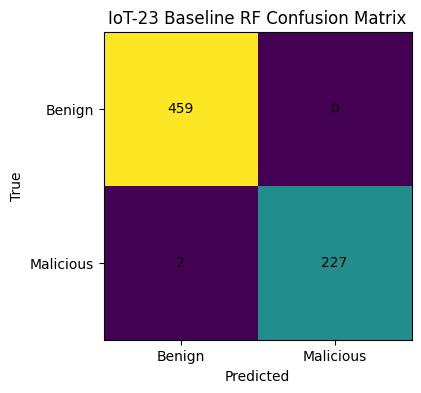

In [25]:
import matplotlib.pyplot as plt

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (5, 4))
plt.imshow(cm)
plt.title("IoT-23 Baseline RF Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0,1], ["Benign", "Malicious"])
plt.yticks([0,1], ["Benign", "Malicious"])

# Annotate the confusion matrix with counts
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha = "center", va = "center")

# Save the confusion matrix plot
out_path = RESULTS_DIR / "iot23_baseline_rf_confusion_matrix.png"
plt.savefig(out_path, bbox_inches = "tight", dpi = 200)
plt.show()


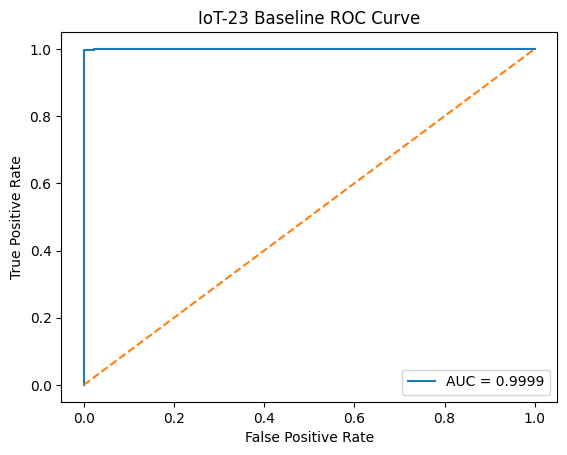

AUC: 0.999904862478713


In [26]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_probs = rf.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label = f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle = "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("IoT-23 Baseline ROC Curve")
plt.legend()
plt.show()

print("AUC:", roc_auc)

      feature  importance
1  orig_bytes    0.354618
0    duration    0.297102
4   resp_pkts    0.201631
3   orig_pkts    0.090975
2  resp_bytes    0.055673


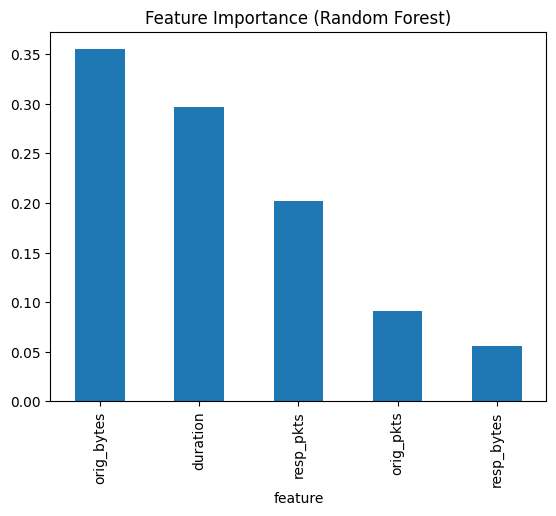

In [27]:
import pandas as pd

# Create a DataFrame for feature importance
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values(by = "importance", ascending = False)

print(importance_df)

# Plot feature importance
importance_df.plot(kind = "bar", x = "feature", y = "importance", legend = False, title = "Feature Importance (Random Forest)")
plt.show()


In [28]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation and compute F1 scores
cv_scores = cross_val_score(rf, X, y, cv = 5, scoring = "f1")

print("Cross-validation F1 scores:", cv_scores)
print("Mean F1:", cv_scores.mean())


Cross-validation F1 scores: [0.98       0.99672131 1.         0.99672131 0.98675497]
Mean F1: 0.9920395179676473


### 6) Logistic Regression Baseline
##### Logistic Regression classifier is trained and evaluated under the same conditions as the Random Forest model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Train a Logistic Regression classifier
log_reg = LogisticRegression(max_iter = 1000, random_state = SEED) 
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       459
           1       0.99      0.97      0.98       229

    accuracy                           0.99       688
   macro avg       0.99      0.98      0.98       688
weighted avg       0.99      0.99      0.99       688

ROC-AUC: 0.9845211252866017


In [ ]:
from sklearn.metrics import f1_score, accuracy_score

# Create a comparison table
results = {
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_lr)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_lr)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_probs),
        roc_auc_score(y_test, y_proba_lr)
    ]
}
comparison_df = pd.DataFrame(results)
comparison_df

,Model,Accuracy,F1 Score,ROC-AUC
0,Random Forest,0.997093,0.995614,0.999905
1,Logistic Regression,0.985465,0.977876,0.984521


In [ ]:
# Will later be used to save the models and report their sizes
import joblib
import os
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

rf_path = models_dir / "rf_model.joblib"
lr_path = models_dir / "log_reg_model.joblib"

joblib.dump(rf, rf_path)
joblib.dump(log_reg, lr_path)

rf_size = os.path.getsize(rf_path) / 1024
lr_size = os.path.getsize(lr_path) / 1024

print(f"Random Forest size: {rf_size:.2f} KB")
print(f"Logistic Regression size: {lr_size:.2f} KB")

Random Forest size: 592.49 KB
Logistic Regression size: 1.19 KB
